# Unit11_Fourier_Transform | 傅立葉轉換與頻譜分析

本 Notebook 使用 `scipy.fft` 模組示範頻譜分析的核心技術，涵蓋幅度頻譜計算、視窗函數、功率頻譜密度（PSD）、短時傅立葉轉換（STFT）以及自相關函數（ACF）等方法，並以化工製程訊號（振動、壓力、溫度）作為應用情境。

## 目標
- 掌握 `scipy.fft` 核心函數（`fft`, `rfft`, `ifft`, `fftfreq`, `rfftfreq`, `fftshift`, `next_fast_len`）的正確使用方式
- 正確計算並歸一化單邊幅度頻譜
- 應用視窗函數抑制頻譜洩漏，理解幅度修正因子
- 估計功率頻譜密度（PSD），實作手動 Welch 法
- 以 `scipy.fft.rfft()` 手動實作 STFT，分析非穩態訊號
- 利用 Wiener-Khinchin 定理，以 FFT 快速計算自相關函數（ACF）

---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit11_Fourier_Transform'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit11'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit11
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit11\outputs\Unit11_Fourier_Transform
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit11\outputs\Unit11_Fourier_Transform\figs


---
### 1. 載入套件

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# scipy.fft — 本課程主要工具
from scipy.fft import (
    fft, ifft, rfft, irfft,
    fftfreq, rfftfreq, fftshift, ifftshift,
    next_fast_len, fft2, fftn
)

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
import scipy
print(f"  numpy      版本: {np.__version__}")
print(f"  scipy      版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
## 2. 取樣定理與離散傅立葉轉換（DFT）

**取樣定理（Nyquist-Shannon）**：訊號最高頻率 $f_{max}$ 須滿足 $f_s \geq 2f_{max}$ ，否則發生**混疊（Aliasing）**。

**奈奎斯特頻率**： $f_N = f_s / 2$ — 可正確分析的最高頻率上限。

**頻率解析度**： $\Delta f = f_s / N = 1 / T_{total}$ — 由總記錄時間決定，與取樣頻率無關。

**DFT 輸出結構**（對 $N$ 點實數訊號）：前 $N/2+1$ 個點包含所有獨立資訊（正頻率），後半為共軛對稱的負頻率。

### 混疊示範


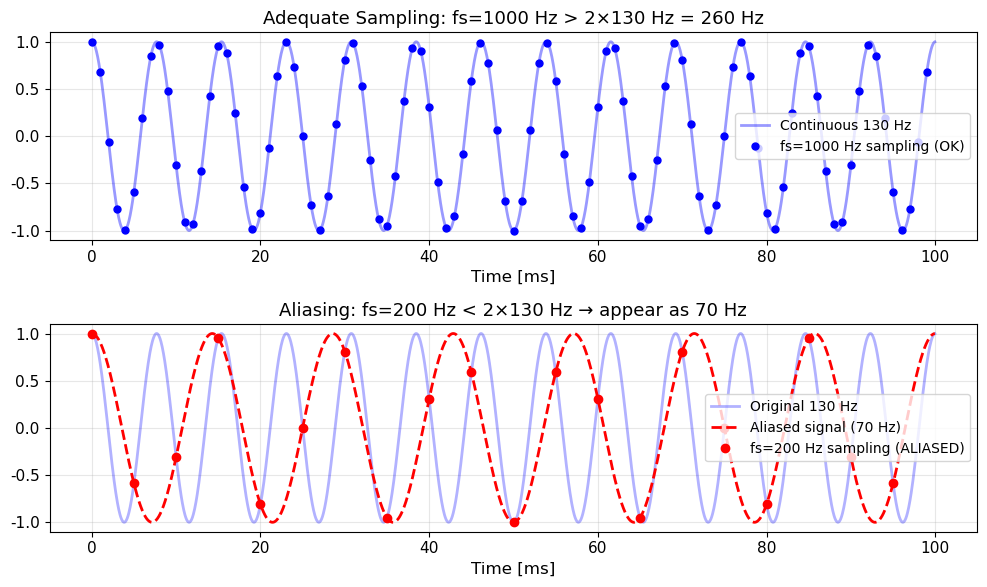

Alias frequency: |130 - 200| = 70 Hz


In [3]:
# ================================================================
# 混疊現象示範：以不足的取樣頻率對 130 Hz 訊號取樣
# ================================================================
f_signal = 130   # 真實頻率 [Hz]
fs_high  = 1000  # 足夠的取樣頻率（符合奈奎斯特：fs >= 2*130 = 260）
fs_low   = 200   # 不足的取樣頻率（fs < 2*130，混疊！）

T = 0.1          # 觀察時間 [s]
t_cont = np.linspace(0, T, 2000, endpoint=False)  # 連續近似

# 兩種取樣方式
t_high = np.arange(0, T, 1/fs_high)
t_low  = np.arange(0, T, 1/fs_low)

x_cont  = np.cos(2 * np.pi * f_signal * t_cont)
x_high  = np.cos(2 * np.pi * f_signal * t_high)
x_low   = np.cos(2 * np.pi * f_signal * t_low)

# 混疊頻率：f_alias = |f_signal - k * fs_low|，k=1 → 130-200=-70 → |70|=70
f_alias = abs(f_signal - fs_low)    # 70 Hz
x_alias = np.cos(2 * np.pi * f_alias * t_cont)   # 混疊後看到的訊號

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

ax = axes[0]
ax.plot(t_cont*1000, x_cont, 'b-', alpha=0.4, label=f'Continuous 130 Hz')
ax.plot(t_high*1000, x_high, 'bo', ms=5, label=f'fs={fs_high} Hz sampling (OK)')
ax.set_title(f'Adequate Sampling: fs={fs_high} Hz > 2×{f_signal} Hz = {2*f_signal} Hz')
ax.set_xlabel('Time [ms]')
ax.legend()

ax = axes[1]
ax.plot(t_cont*1000, x_cont, 'b-', alpha=0.3, label=f'Original 130 Hz')
ax.plot(t_cont*1000, x_alias, 'r--', label=f'Aliased signal ({f_alias} Hz)')
ax.plot(t_low*1000, x_low, 'ro', ms=6, label=f'fs={fs_low} Hz sampling (ALIASED)')
ax.set_title(f'Aliasing: fs={fs_low} Hz < 2×{f_signal} Hz → appear as {f_alias} Hz')
ax.set_xlabel('Time [ms]')
ax.legend()

plt.tight_layout()
fig.savefig(FIG_DIR / 'aliasing_demo.png', bbox_inches='tight')
plt.show()
print(f"Alias frequency: |{f_signal} - {fs_low}| = {f_alias} Hz")

---
## 3. scipy.fft 模組：幅度頻譜計算

### 3.1 單邊幅度頻譜（推薦做法）

對實數訊號，使用 `rfft()` 計算，只輸出 $\lfloor N/2 \rfloor + 1$ 個獨立複數，效率更高。

**幅度歸一化**：
- DC（ $k=0$ ）：除以 $N$
- 一般頻率（ $k=1\sim N/2-1$ ）：乘以 $2/N$ （合併正負頻率）
- 奈奎斯特（ $k=N/2$ ， $N$ 為偶數）：除以 $N$

```python
X_r = rfft(x)
amplitude = (2 / N) * np.abs(X_r)
amplitude[0] /= 2          # DC
if N % 2 == 0: amplitude[-1] /= 2  # Nyquist
freqs = rfftfreq(N, d=1/fs)
```

### 3.2 合成訊號驗證幅度校正


50 Hz  振幅: 2.9887  (理論值: 3.0000)
120 Hz 振幅: 1.5086  (理論值: 1.5000)


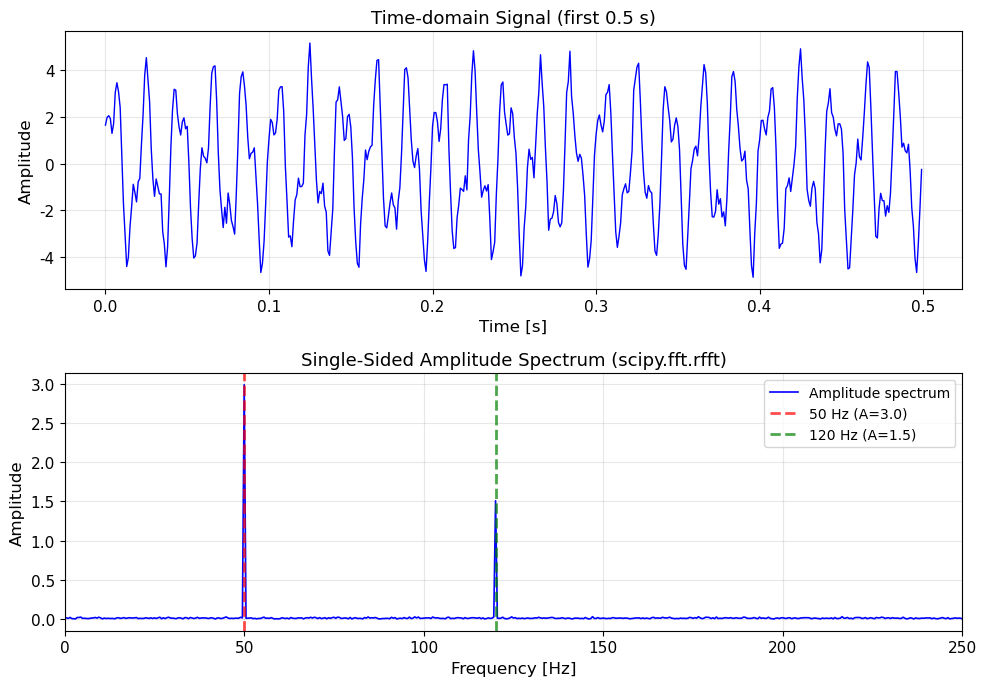

In [4]:
# ================================================================
# 合成訊號幅度頻譜：x(t) = 3sin(2π·50t) + 1.5cos(2π·120t) + 雜訊
# 目標：驗證幅度歸一化後是否正確還原振幅 3.0 和 1.5
# ================================================================
fs = 1000       # 取樣頻率 [Hz]
T  = 2.0        # 訊號長度 [s]
N  = int(fs * T)
t  = np.linspace(0, T, N, endpoint=False)

# 合成訊號（含高斯雜訊）
np.random.seed(42)
x = (3.0 * np.sin(2*np.pi*50*t)
   + 1.5 * np.cos(2*np.pi*120*t)
   + 0.3 * np.random.randn(N))

# --- scipy.fft 計算單邊幅度頻譜 ---
X_r = rfft(x)
amplitude = (2 / N) * np.abs(X_r)
amplitude[0] /= 2                   # DC 分量（不乘 2）
if N % 2 == 0:
    amplitude[-1] /= 2              # 奈奎斯特（不乘 2，N 為偶數）
freqs = rfftfreq(N, d=1/fs)

# 找峰值
peak_50  = np.argmax(amplitude[(freqs > 45) & (freqs < 55)])
peak_120 = np.argmax(amplitude[(freqs > 115) & (freqs < 125)])
amp_50   = amplitude[(freqs > 45) & (freqs < 55)][peak_50]
amp_120  = amplitude[(freqs > 115) & (freqs < 125)][peak_120]
print(f"50 Hz  振幅: {amp_50:.4f}  (理論值: 3.0000)")
print(f"120 Hz 振幅: {amp_120:.4f}  (理論值: 1.5000)")

# --- 繪圖 ---
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

ax = axes[0]
ax.plot(t[:500], x[:500], 'b-', lw=1)
ax.set_title('Time-domain Signal (first 0.5 s)')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Amplitude')

ax = axes[1]
ax.plot(freqs, amplitude, 'b-', lw=1.2, label='Amplitude spectrum')
ax.axvline(50,  color='r', ls='--', alpha=0.7, label='50 Hz (A=3.0)')
ax.axvline(120, color='g', ls='--', alpha=0.7, label='120 Hz (A=1.5)')
ax.set_xlim([0, 250])
ax.set_title('Single-Sided Amplitude Spectrum (scipy.fft.rfft)')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Amplitude')
ax.legend()

plt.tight_layout()
fig.savefig(FIG_DIR / 'amplitude_spectrum.png', bbox_inches='tight')
plt.show()

---
## 4. 視窗函數與頻譜洩漏

頻譜洩漏成因：截斷等效於乘以矩形視窗，其傅立葉轉換是 sinc 函數（含旁葉）。

**套用視窗函數後的幅度修正**：

$$\text{修正振幅} = \frac{2}{N} \cdot \frac{|X_r[k]|}{\text{CG}}, \quad \text{CG} = \frac{\sum w[n]}{N}$$

| 視窗 | numpy 函數 | 相干增益 CG | 最大旁葉幅度 |
|------|-----------|-----------|------------|
| Rectangular | `np.ones(N)` | 1.000 | -13 dB |
| Hann | `np.hanning(N)` | 0.500 | -32 dB |
| Hamming | `np.hamming(N)` | 0.540 | -43 dB |
| Blackman | `np.blackman(N)` | 0.420 | -58 dB |

### 視窗函數效果比較

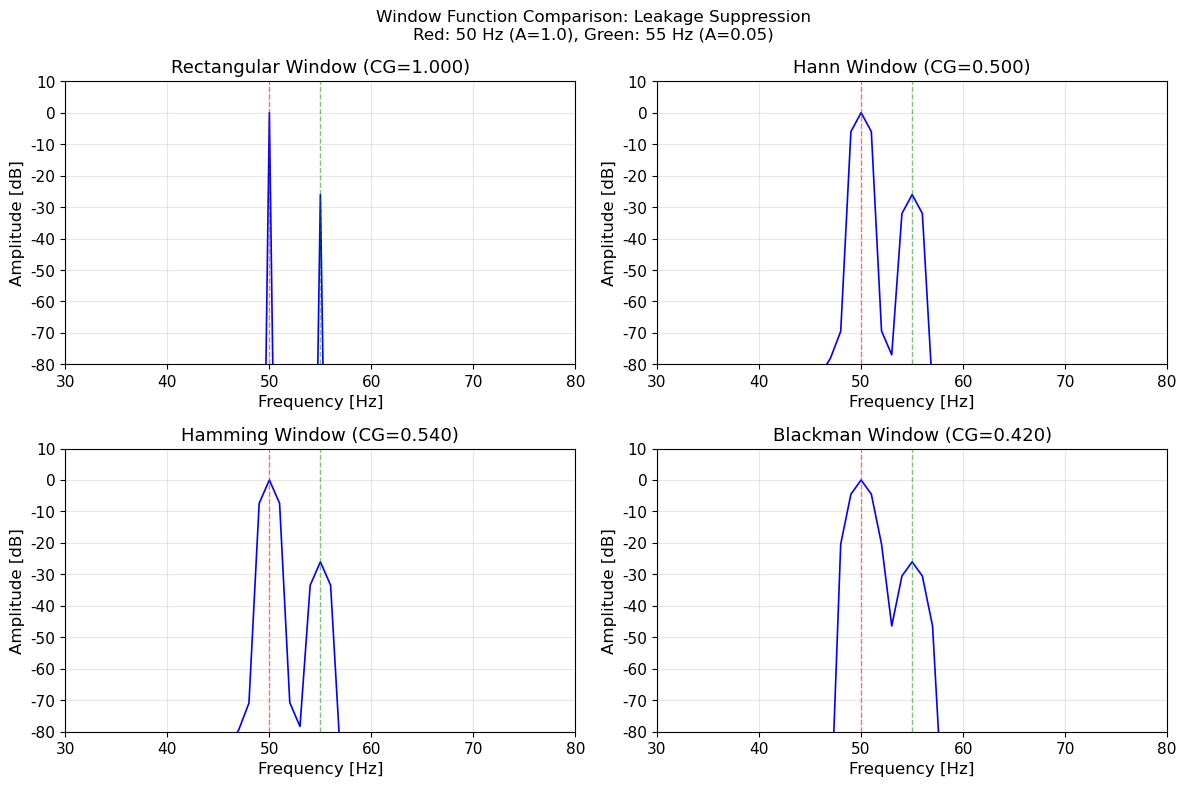

Hann & Blackman windows: 55 Hz weak peak is visible; Rectangular: masked by leakage


In [5]:
# ================================================================
# 視窗函數比較：強弱訊號混存時的頻譜洩漏效果
# 訊號：f1=50Hz(A=1.0) + f2=55Hz(A=0.05) 密集頻率
# ================================================================
fs = 1000
T  = 1.0
N  = int(fs * T)
t  = np.linspace(0, T, N, endpoint=False)

# 兩個密集頻率訊號（振幅差 20 倍，考驗弱訊號的可見性）
x_win = (1.0 * np.sin(2*np.pi*50*t)
       + 0.05 * np.sin(2*np.pi*55*t))

windows = {
    'Rectangular': np.ones(N),
    'Hann':        np.hanning(N),
    'Hamming':     np.hamming(N),
    'Blackman':    np.blackman(N),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (name, win) in zip(axes, windows.items()):
    cg = np.sum(win) / N                # 相干增益
    X_r = rfft(x_win * win)
    amp = (2 / N) * np.abs(X_r) / cg   # 幅度修正
    amp[0] /= 2
    freqs_w = rfftfreq(N, d=1/fs)

    ax.plot(freqs_w, 20 * np.log10(amp + 1e-12), 'b-', lw=1.2)
    ax.axvline(50, color='r', ls='--', alpha=0.5, lw=1)
    ax.axvline(55, color='g', ls='--', alpha=0.5, lw=1)
    ax.set_xlim([30, 80])
    ax.set_ylim([-80, 10])
    ax.set_title(f'{name} Window (CG={cg:.3f})')
    ax.set_xlabel('Frequency [Hz]')
    ax.set_ylabel('Amplitude [dB]')

plt.suptitle('Window Function Comparison: Leakage Suppression\n'
             'Red: 50 Hz (A=1.0), Green: 55 Hz (A=0.05)',
             fontsize=12)
plt.tight_layout()
fig.savefig(FIG_DIR / 'window_comparison.png', bbox_inches='tight')
plt.show()
print("Hann & Blackman windows: 55 Hz weak peak is visible; Rectangular: masked by leakage")

---
## 5. 功率頻譜密度（PSD）

**週期圖法**： $\hat{S}(f_k) = \frac{1}{f_s \cdot N} |X[k]|^2$ ，方差不隨 $N$ 降低（不一致估計）。

**Welch 法**：分段（50% 重疊 + Hann 視窗）後取平均，顯著降低方差（犧牲頻率解析度）。

**Parseval 定理**： $\int_0^{f_N} S(f)\, df \approx \overline{x^2}$ （PSD 積分 = 訊號均方功率）

### Welch 法手動實作與 scipy.signal.welch 比較


Parseval 驗證 (Welch):
  時域均方功率: 3.0521
  PSD 積分功率: 3.0538
  誤差: 0.06%


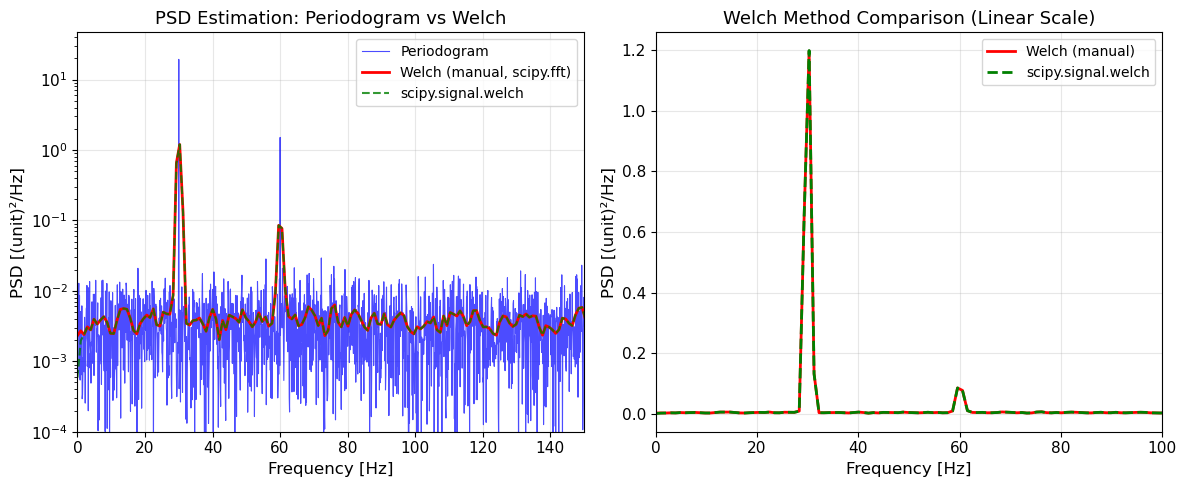

In [6]:
# ================================================================
# PSD 估計：週期圖 vs Welch 法（手動 scipy.fft 實作）
# 訊號：製程壓力振動（含隨機雜訊的週期訊號）
# ================================================================
fs = 500       # 取樣頻率 [Hz]
T  = 10.0      # 10 秒長訊號
N  = int(fs * T)
t  = np.linspace(0, T, N, endpoint=False)

# 模擬製程壓力訊號：30 Hz 主頻 + 60 Hz 二次諧波 + 隨機雜訊
np.random.seed(0)
signal_psd = (2.0 * np.sin(2*np.pi*30*t) + 0.5 * np.sin(2*np.pi*60*t)
              + 1.0 * np.random.randn(N))

# ---- 週期圖法（直接 rfft）----
X_r = rfft(signal_psd)
psd_periodogram = (1 / (fs * N)) * np.abs(X_r)**2
psd_periodogram[1:-1] *= 2
freqs_psd = rfftfreq(N, d=1/fs)

# ---- 手動 Welch 法（scipy.fft 實作）----
def welch_manual(x, fs, nperseg=256, noverlap=None):
    if noverlap is None:
        noverlap = nperseg // 2
    win = np.hanning(nperseg)
    step = nperseg - noverlap
    n_segs = (len(x) - noverlap) // step
    freqs_w = rfftfreq(nperseg, d=1/fs)
    psd_sum = np.zeros(nperseg // 2 + 1)
    for i in range(n_segs):
        seg = x[i*step : i*step+nperseg] * win
        Xs = rfft(seg)
        ps = (1 / (fs * np.sum(win**2))) * np.abs(Xs)**2
        ps[1:-1] *= 2
        psd_sum += ps
    return freqs_w, psd_sum / n_segs

freqs_w, psd_welch_manual = welch_manual(signal_psd, fs, nperseg=512)

# ---- scipy.signal.welch（補充說明）----
import scipy.signal as ssignal
freqs_ss, psd_scipy = ssignal.welch(signal_psd, fs=fs, nperseg=512,
                                     noverlap=256, window='hann')

# ---- Parseval 定理驗證（Welch 法）----
power_time = np.mean(signal_psd**2)
power_freq = np.sum(psd_welch_manual) * (freqs_w[1] - freqs_w[0])
print(f"Parseval 驗證 (Welch):")
print(f"  時域均方功率: {power_time:.4f}")
print(f"  PSD 積分功率: {power_freq:.4f}")
print(f"  誤差: {abs(power_time - power_freq)/power_time*100:.2f}%")

# ---- 繪圖 ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.semilogy(freqs_psd, psd_periodogram, 'b-', lw=0.8, alpha=0.7, label='Periodogram')
ax.semilogy(freqs_w, psd_welch_manual, 'r-', lw=2, label='Welch (manual, scipy.fft)')
ax.semilogy(freqs_ss, psd_scipy, 'g--', lw=1.5, alpha=0.8, label='scipy.signal.welch')
ax.set_xlim([0, 150])
ax.set_title('PSD Estimation: Periodogram vs Welch')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('PSD [(unit)²/Hz]')
ax.legend()
ax.set_ylim(bottom=1e-4)

ax = axes[1]
ax.plot(freqs_w, psd_welch_manual, 'r-', lw=2, label='Welch (manual)')
ax.plot(freqs_ss, psd_scipy, 'g--', lw=2, label='scipy.signal.welch')
ax.set_xlim([0, 100])
ax.set_title('Welch Method Comparison (Linear Scale)')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('PSD [(unit)²/Hz]')
ax.legend()

plt.tight_layout()
fig.savefig(FIG_DIR / 'psd_welch.png', bbox_inches='tight')
plt.show()

---
## 6. 短時傅立葉轉換（STFT）

對**非穩態訊號**（頻率隨時間變化），標準 FFT 只能給出整段時間的「平均」頻譜。

STFT 解決方案：以**滑動視窗**逐段計算 FFT，得到**時頻二維表示**（頻譜圖）。

**時頻取捨**：視窗越長 → 頻率解析度高；視窗越短 → 時間解析度高。

原則：視窗內至少包含目標頻率的 **2\~5 個週期**（ $L \geq 2\sim5 \cdot f_s / f_{target}$ ）。

### 線性調頻訊號（Chirp）+ 手動 STFT 示範


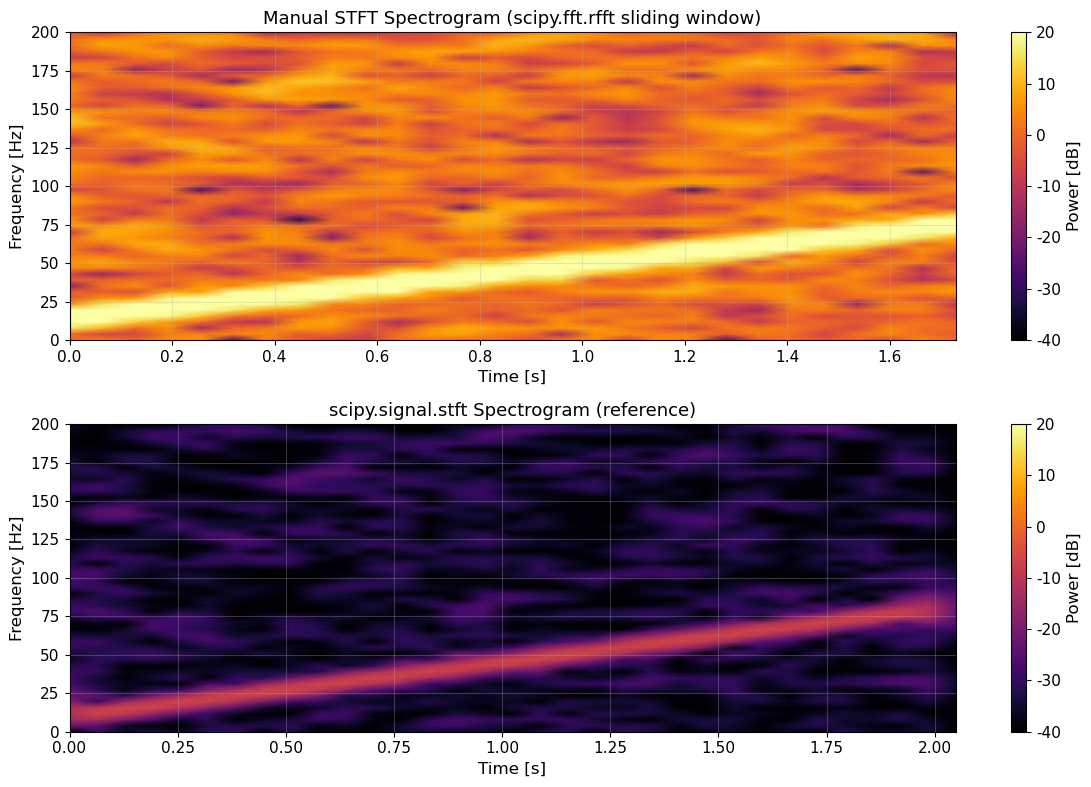

Chirp: frequency increases linearly from 10 Hz to 80 Hz over 2 seconds


In [7]:
# ================================================================
# 手動 STFT + 頻譜圖（使用 scipy.fft.rfft）
# 訊號：chirp（線性調頻，0→2s 從 10 Hz 升至 80 Hz）
# ================================================================
import scipy.signal as ssignal

fs_stft = 500       # 取樣頻率 [Hz]
T_stft  = 2.0       # 時間長度 [s]
N_stft  = int(fs_stft * T_stft)
t_stft  = np.linspace(0, T_stft, N_stft, endpoint=False)

# 產生 chirp 訊號（scipy.signal 僅用於生成測試訊號）
x_chirp = ssignal.chirp(t_stft, f0=10, f1=80, t1=T_stft, method='linear')
x_chirp += 0.2 * np.random.randn(N_stft)

# ---- 手動 STFT（使用 scipy.fft.rfft）----
def stft_manual(x, fs, window_len=128, hop=64):
    window = np.hanning(window_len)
    freqs_s = rfftfreq(window_len, d=1/fs)
    n_frames = (len(x) - window_len) // hop + 1
    times_s = np.array([i * hop / fs for i in range(n_frames)])
    spec = np.zeros((len(freqs_s), n_frames), dtype=complex)
    for i in range(n_frames):
        start = i * hop
        frame = x[start:start + window_len] * window
        spec[:, i] = rfft(frame)
    return freqs_s, times_s, spec

freqs_stft, times_stft, spec = stft_manual(x_chirp, fs_stft, window_len=128, hop=32)
spec_db = 10 * np.log10(np.abs(spec)**2 + 1e-10)

# ---- 比較：scipy.signal.stft ----
f_sp, t_sp, Zxx = ssignal.stft(x_chirp, fs=fs_stft, nperseg=128, noverlap=96)
Zxx_db = 10 * np.log10(np.abs(Zxx)**2 + 1e-10)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

ax = axes[0]
pcm = ax.pcolormesh(times_stft, freqs_stft, spec_db, shading='gouraud',
                     cmap='inferno', vmin=-40, vmax=20)
plt.colorbar(pcm, ax=ax, label='Power [dB]')
ax.set_title('Manual STFT Spectrogram (scipy.fft.rfft sliding window)')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Frequency [Hz]')
ax.set_ylim([0, 200])

ax = axes[1]
pcm2 = ax.pcolormesh(t_sp, f_sp, Zxx_db, shading='gouraud',
                      cmap='inferno', vmin=-40, vmax=20)
plt.colorbar(pcm2, ax=ax, label='Power [dB]')
ax.set_title('scipy.signal.stft Spectrogram (reference)')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Frequency [Hz]')
ax.set_ylim([0, 200])

plt.tight_layout()
fig.savefig(FIG_DIR / 'stft_spectrogram.png', bbox_inches='tight')
plt.show()
print("Chirp: frequency increases linearly from 10 Hz to 80 Hz over 2 seconds")

---
## 7. 自相關函數（ACF）與 Wiener-Khinchin 定理

**Wiener-Khinchin 定理**：PSD = ACF 的傅立葉轉換

$$R_x[m] = \text{IFFT}\bigl(|X[k]|^2\bigr) \quad \Longrightarrow \quad O(N\log N) \text{ 替代 } O(N^2) \text{ 直接計算}$$

**關鍵性質**：
- $R_x(0)$ = 訊號能量（或均方功率）
- 週期訊號的 ACF 仍為同週期週期函數 → 可用 ACF 峰值間距估計訊號週期

### ACF 應用：估計製程訊號週期

ACF 估計週期: 0.1000 s
理論週期:     0.1000 s
估計基本頻率: 10.00 Hz（理論: 10 Hz）


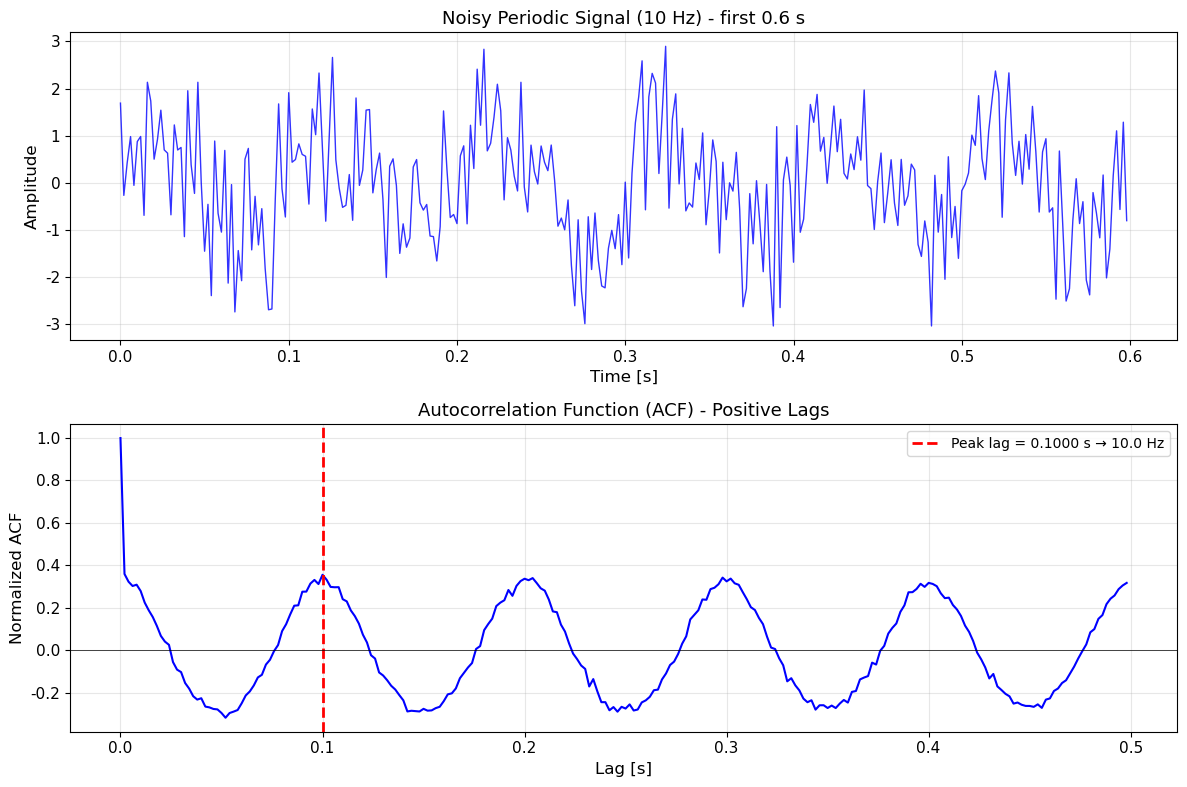

In [10]:

# ================================================================
# ACF 計算（Wiener-Khinchin + scipy.fft）
# 應用：估計含雜訊的週期性訊號的基本週期
# ================================================================

def acf_fft(x, normalize=True):
    # 以 FFT 計算自相關函數（Wiener-Khinchin 定理）
    N = len(x)
    N_fft = next_fast_len(2 * N - 1)    # 零填充，避免循環相關
    X = rfft(x, n=N_fft)
    power_spectrum = np.abs(X)**2
    acf_full = irfft(power_spectrum, n=N_fft).real
    # 排列：lag = -(N-1) 到 (N-1)
    acf_out = np.concatenate([acf_full[-(N-1):], acf_full[:N]])
    if normalize:
        acf_out = acf_out / acf_out[N - 1]   # ACF(0) = 1
    lags = np.arange(-(N-1), N)
    return lags, acf_out

# 模擬含雜訊的製程溫度訊號（真實週期 = 0.1 s）
fs_acf = 500
T_acf  = 5.0
N_acf  = int(fs_acf * T_acf)
t_acf  = np.linspace(0, T_acf, N_acf, endpoint=False)

f0_acf  = 10          # 基本頻率 [Hz]，週期 = 1/10 = 0.1 s
np.random.seed(7)
x_acf = (np.sin(2*np.pi*f0_acf*t_acf)
        + 0.3*np.sin(2*np.pi*2*f0_acf*t_acf)   # 2nd harmonic
        + 1.0*np.random.randn(N_acf))            # moderate-heavy noise

lags_acf, acf_vals = acf_fft(x_acf, normalize=True)

# 取正延遲部分
pos_lags = lags_acf[N_acf-1:]          # lag = 0, 1, ..., N-1
pos_acf  = acf_vals[N_acf-1:]
lag_time = pos_lags / fs_acf           # 轉換為時間 [s]

# 找第一個正局部峰值（lag > 0）：估計週期
# min_dist 設為 0.5 倍最短可能週期，濾除短暫雜訊假峰
from scipy.signal import find_peaks as sp_find_peaks

search_end  = int(0.4 * fs_acf)                   # 搜尋 0~0.4 s 範圍
min_dist    = int(0.05 * fs_acf)                   # 最小峰值間距 25 samples = 0.05 s
peak_indices, _ = sp_find_peaks(
    pos_acf[1:search_end],
    height=0.05,
    distance=min_dist
)
if len(peak_indices) > 0:
    # 取振幅最高的峰值（對應最強週期分量）
    best = peak_indices[np.argmax(pos_acf[1:search_end][peak_indices])]
    peak_idx = best + 1    # +1 因搜尋從 index 1 開始
else:
    peak_idx = np.argmax(pos_acf[1:search_end]) + 1   # 回退方案

estimated_T = peak_idx / fs_acf
print(f"ACF 估計週期: {estimated_T:.4f} s")
print(f"理論週期:     {1/f0_acf:.4f} s")
print(f"估計基本頻率: {1/estimated_T:.2f} Hz（理論: {f0_acf} Hz）")

# ---- 繪圖 ----
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

ax = axes[0]
ax.plot(t_acf[:300], x_acf[:300], 'b-', lw=1, alpha=0.8)
ax.set_title(f'Noisy Periodic Signal ({f0_acf} Hz) - first 0.6 s')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Amplitude')

ax = axes[1]
max_lag_show = int(5 / f0_acf * fs_acf)   # 顯示 5 個週期範圍
ax.plot(lag_time[:max_lag_show], pos_acf[:max_lag_show], 'b-', lw=1.5)
ax.axvline(estimated_T, color='r', ls='--', lw=2,
           label=f'Peak lag = {estimated_T:.4f} s → {1/estimated_T:.1f} Hz')
ax.axhline(0, color='k', ls='-', lw=0.5)
ax.set_title('Autocorrelation Function (ACF) - Positive Lags')
ax.set_xlabel('Lag [s]')
ax.set_ylabel('Normalized ACF')
ax.legend()

plt.tight_layout()
fig.savefig(FIG_DIR / 'acf_period_estimation.png', bbox_inches='tight')
plt.show()


---
## 8. 頻譜分析前處理最佳實踐

### 前處理流程摘要

| 步驟 | 目的 | 方法 |
|------|------|------|
| 去均值 | 消除 DC 偏移（避免高 DC 峰掩蓋其他頻率） | `x -= np.mean(x)` |
| 去趨勢 | 消除線性漂移（避免低頻能量污染） | `np.polyfit` 一次多項式 |
| 零填充 | 加速 FFT，使頻率軸更密（非提升解析度） | `next_fast_len(2*N)` |
| 套用視窗 | 抑制頻譜洩漏 | Hann（預設） |
| 幅度歸一化 | 還原真實振幅 | 除以 N（非 N\_fft） |

### 完整前處理範例

原始點數 N = 800, 零填充後 N_fft = 1600
25 Hz 振幅（前處理後）: 1.0351（理論值: 1.0000）


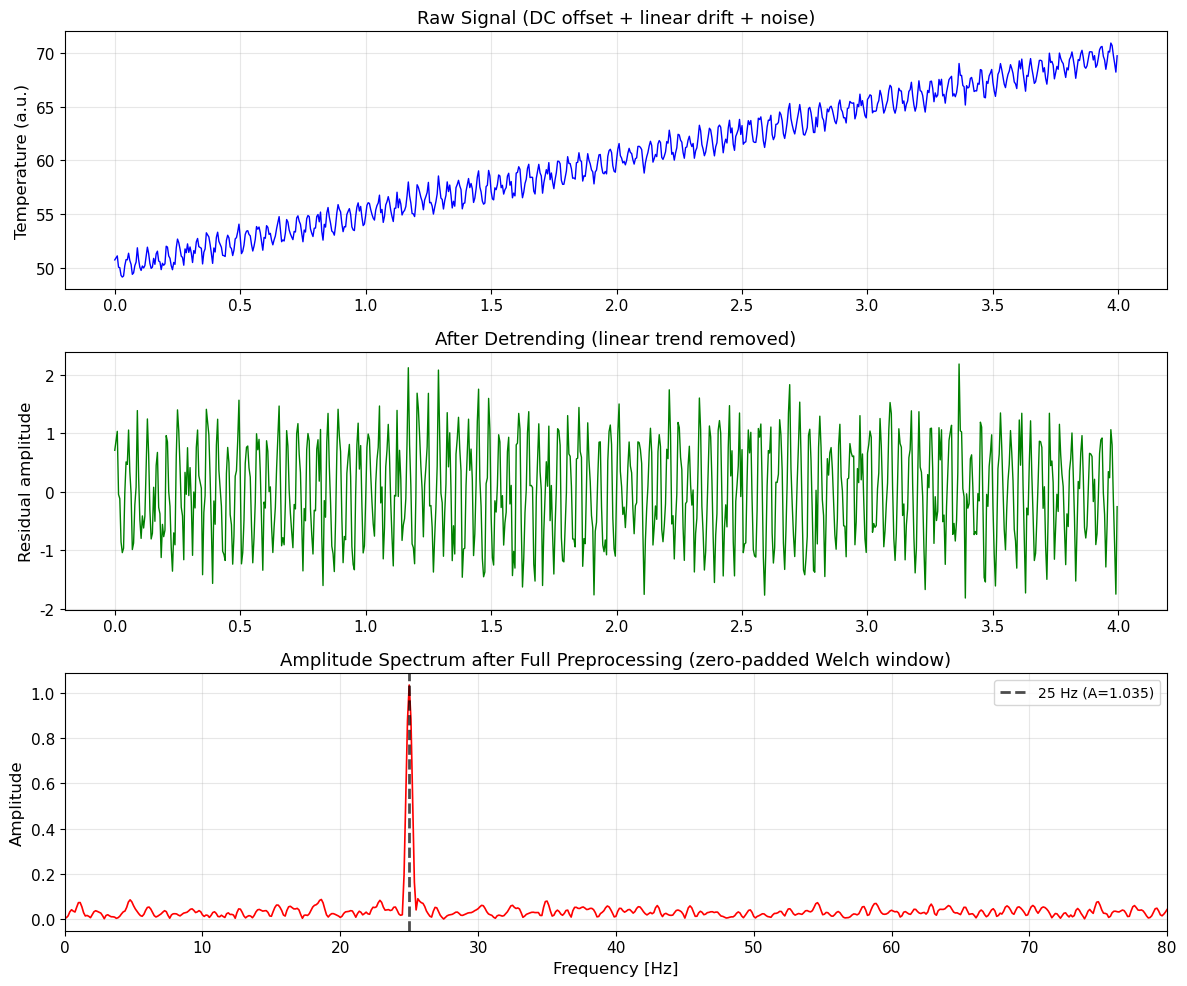

In [11]:
# ================================================================
# 完整前處理流程示範：帶 DC 偏移 + 線性漂移的製程溫度訊號
# ================================================================
fs_pre = 200       # 取樣頻率 [Hz]
T_pre  = 4.0
N_pre  = int(fs_pre * T_pre)
t_pre  = np.linspace(0, T_pre, N_pre, endpoint=False)

np.random.seed(3)
# 模擬製程溫度：真實振動頻率 25 Hz（A=1.0），加入 DC 偏移 + 線性漂移 + 雜訊
trend    = 50 + 5 * t_pre                          # DC=50, 線性漂移 5/s
x_raw    = trend + np.sin(2*np.pi*25*t_pre) + 0.4*np.random.randn(N_pre)

# ---- Step 1: 去趨勢（移除線性漂移 + DC）----
coeff = np.polyfit(t_pre, x_raw, deg=1)
x_detrend = x_raw - np.polyval(coeff, t_pre)

# ---- Step 2: 套用 Hann 視窗 ----
window_pre = np.hanning(N_pre)
cg = np.sum(window_pre) / N_pre
x_windowed = x_detrend * window_pre

# ---- Step 3: 零填充至最佳 FFT 點數 ----
N_fft_pre = next_fast_len(2 * N_pre)    # 找 >= 2*N 的快速點數
print(f"原始點數 N = {N_pre}, 零填充後 N_fft = {N_fft_pre}")

# ---- Step 4: 計算 rfft，幅度歸一化（除以原始 N，非 N_fft）----
X_pre = rfft(x_windowed, n=N_fft_pre)
amplitude_pre = (2 / N_pre) * np.abs(X_pre) / cg   # 注意：除以 N_pre
amplitude_pre[0] /= 2
freqs_pre = rfftfreq(N_fft_pre, d=1/fs_pre)

# ---- 找 25 Hz 峰值 ----
mask_25 = (freqs_pre > 20) & (freqs_pre < 30)
amp_25 = amplitude_pre[mask_25].max()
print(f"25 Hz 振幅（前處理後）: {amp_25:.4f}（理論值: 1.0000）")

# ---- 繪圖 ----
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

ax = axes[0]
ax.plot(t_pre, x_raw, 'b-', lw=1)
ax.set_title('Raw Signal (DC offset + linear drift + noise)')
ax.set_ylabel('Temperature (a.u.)')

ax = axes[1]
ax.plot(t_pre, x_detrend, 'g-', lw=1)
ax.set_title('After Detrending (linear trend removed)')
ax.set_ylabel('Residual amplitude')

ax = axes[2]
ax.plot(freqs_pre, amplitude_pre, 'r-', lw=1.2)
ax.axvline(25, color='k', ls='--', alpha=0.7, label=f'25 Hz (A={amp_25:.3f})')
ax.set_xlim([0, 80])
ax.set_title('Amplitude Spectrum after Full Preprocessing (zero-padded Welch window)')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Amplitude')
ax.legend()

plt.tight_layout()
fig.savefig(FIG_DIR / 'preprocessing_demo.png', bbox_inches='tight')
plt.show()

---
## 9. scipy.signal 模組簡介（補充）

> **說明**：本節僅作簡要介紹，`scipy.signal` 不在本課程教授範圍。

以下示範 `scipy.signal` 常用函數，並與本課程的 `scipy.fft` 手動實作比較結果一致性。

| 函數 | 功能 |
|------|------|
| `signal.welch(x, fs, nperseg)` | Welch PSD（等同手動 Welch 法） |
| `signal.stft(x, fs, nperseg, noverlap)` | STFT（等同手動 STFT） |
| `signal.spectrogram(x, fs)` | 計算頻譜圖（含時間、頻率、功率） |
| `signal.chirp(t, f0, f1, t1)` | 生成線性調頻訊號 |
| `signal.find_peaks(x, prominence)` | 自動峰值偵測 |
| `signal.get_window(window, N)` | 取得視窗函數陣列 |

### scipy.signal.find_peaks 自動峰值偵測（補充示範）

偵測到 3 個峰值頻率：
  50.0 Hz  (幅度: 2.0059)
  100.0 Hz  (幅度: 0.7995)
  150.0 Hz  (幅度: 0.3026)


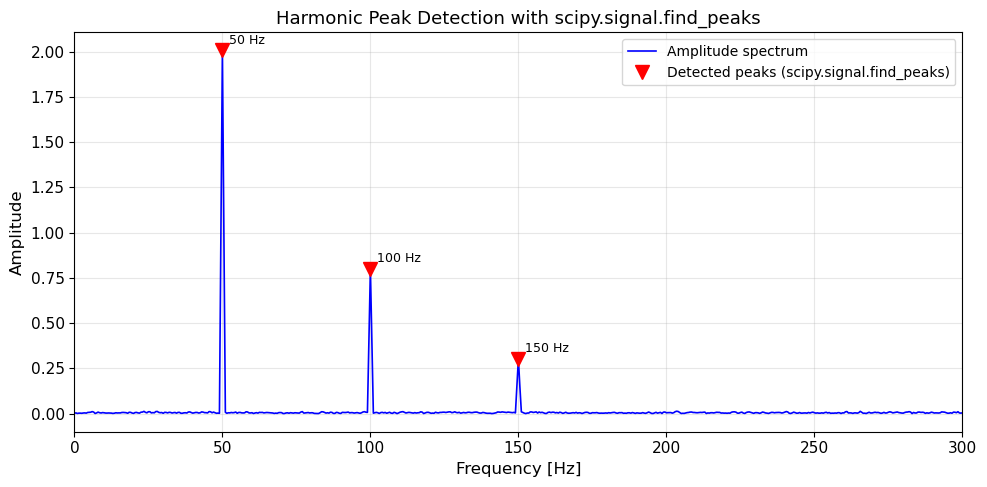

In [12]:
# ================================================================
# scipy.signal.find_peaks 示範：自動識別幅度頻譜峰值
# ================================================================
import scipy.signal as ssignal

# 多頻率訊號：模擬設備振動（基頻 + 諧波）
fs_pk = 1000
T_pk  = 2.0
N_pk  = int(fs_pk * T_pk)
t_pk  = np.linspace(0, T_pk, N_pk, endpoint=False)

np.random.seed(99)
x_pk = (2.0 * np.sin(2*np.pi*50*t_pk)    # 基頻 50 Hz
      + 0.8 * np.sin(2*np.pi*100*t_pk)   # 2nd harmonic
      + 0.3 * np.sin(2*np.pi*150*t_pk)   # 3rd harmonic
      + 0.1 * np.random.randn(N_pk))

# 計算幅度頻譜（已前處理：去均值 + Hann 視窗）
x_pk -= np.mean(x_pk)
win_pk = np.hanning(N_pk)
cg_pk  = np.sum(win_pk) / N_pk
X_pk   = rfft(x_pk * win_pk)
amp_pk = (2 / N_pk) * np.abs(X_pk) / cg_pk
amp_pk[0] /= 2
freqs_pk = rfftfreq(N_pk, d=1/fs_pk)

# ---- scipy.signal.find_peaks 偵測峰值（補充示範）----
# 找出幅度 > 5% 最大值，且與相鄰峰值間距 >= 20 bins 的峰值
peaks_idx, _ = ssignal.find_peaks(amp_pk,
                                   prominence=0.05 * amp_pk.max(),
                                   distance=20)

print(f"偵測到 {len(peaks_idx)} 個峰值頻率：")
for idx in peaks_idx:
    if freqs_pk[idx] < 300:
        print(f"  {freqs_pk[idx]:.1f} Hz  (幅度: {amp_pk[idx]:.4f})")

# ---- 繪圖 ----
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(freqs_pk, amp_pk, 'b-', lw=1.2, label='Amplitude spectrum')
ax.plot(freqs_pk[peaks_idx], amp_pk[peaks_idx], 'rv',
        ms=10, label='Detected peaks (scipy.signal.find_peaks)')
for idx in peaks_idx:
    if freqs_pk[idx] < 300:
        ax.annotate(f'{freqs_pk[idx]:.0f} Hz',
                    (freqs_pk[idx], amp_pk[idx]),
                    xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.set_xlim([0, 300])
ax.set_title('Harmonic Peak Detection with scipy.signal.find_peaks')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Amplitude')
ax.legend()

plt.tight_layout()
fig.savefig(FIG_DIR / 'peak_detection.png', bbox_inches='tight')
plt.show()

---

## 本單元程式演練總結

| 節次 | 主題 | 核心函數 | 圖檔輸出 |
|------|------|---------|---------|
| Sec.2 | 混疊示範 | `np.cos`, `rfft` | `aliasing_demo.png` |
| Sec.3 | 單邊幅度頻譜 | `rfft`, `rfftfreq` | `amplitude_spectrum.png` |
| Sec.4 | 視窗函數比較 | `np.hanning`, `np.blackman` | `window_comparison.png` |
| Sec.5 | PSD（週期圖 vs Welch） | `rfft`, 手動 Welch | `psd_welch.png` |
| Sec.6 | STFT 頻譜圖 | `rfft` 滑動視窗 | `stft_spectrogram.png` |
| Sec.7 | ACF + 週期估計 | `rfft`, `irfft`, `next_fast_len` | `acf_period_estimation.png` |
| Sec.8 | 前處理標準流程 | `polyfit`, `next_fast_len`, `rfft` | `preprocessing_demo.png` |
| Sec.9 | scipy.signal 峰值偵測 | `signal.find_peaks` | `peak_detection.png` |

---

**課程資訊**
- 課程名稱：電腦在化工上之應用 (ChemE 3502)
- 課程單元：Unit11 傅立葉轉換與頻譜分析
- 課程製作：逢甲大學 化工系 智慧程序系統工程實驗室
- 授課教師：莊曜禎 助理教授
- 更新日期：2026-02-24

**課程授權 [CC BY-NC-SA 4.0]**
 - 本教材遵循 [創用CC 姓名標示-非商業性-相同方式分享 4.0 國際 (CC BY-NC-SA 4.0)](https://creativecommons.org/licenses/by-nc-sa/4.0/deed.zh) 授權。

---
